# Lab: Polynomial Regression

**Linear regression** can only draw a straight line; however, if we transform `X` into `[X, X², X³, …]` using `PolynomialFeatures`, that **same `LinearRegression`** model learns to fit curves. We also saw that the **degree is a hyperparameter**: we don't know it beforehand, so we must test and validate it.

In this lab, you will:

1. Reproduce the **7-house** example from class using scikit-learn.
2. Work with a **300-house dataset** that exhibits the same behavior (price accelerates as square footage increases).
3. Observe why a straight line fails by examining the **residual plot**.
4. Understand the internal workings of `PolynomialFeatures` (`X_poly`, `shape`, columns).
5. Compare **degrees 1 through 10** using **train vs. test** splits and observe overfitting.
6. Select the optimal degree using **cross-validation**: `cross_val_score`, `validation_curve`, and `GridSearchCV` within a `Pipeline`.
7. Apply these concepts to a **real scikit-learn dataset** (`load_diabetes`) and discover that cross-validation can also indicate when a curve is unnecessary.

---
## 0 Setup

We import everything and define the class palette.

In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures

from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.model_selection import train_test_split, KFold, cross_val_score, validation_curve, GridSearchCV

from sklearn.metrics import mean_squared_error, r2_score

# Class palette: colors are part of the pedagogy
C = dict(bg="#0D1520", panel="#152232", grid="#26384D", text="#E8EEF4", sec="#9DB2C6",
        data="#E879F9",   # real data
        x="#3499CF",      # original X
        x2="#22D3EE",     # X²
        x3="#A78BFA",     # X³
        lin="#F05133",    # linear regression (straight line)
        poly="#4ADE80",   # polynomial regression (curve)
        deg="#FBBF24",    # degree / hyperparameter
        err="#F87171")    # error / residuals

plt.rcParams.update({
    "figure.facecolor": C["bg"], "axes.facecolor": C["panel"], "axes.edgecolor": C["grid"],
    "axes.labelcolor": C["sec"], "xtick.color": C["sec"], "ytick.color": C["sec"],
    "text.color": C["text"], "grid.color": C["grid"], "axes.grid": True, "grid.alpha": 0.6,
    "legend.facecolor": C["panel"], "legend.edgecolor": C["grid"], "font.size": 11,
    "axes.titleweight": "bold", "figure.dpi": 110,
})

RNG = np.random.default_rng(32)

print("scikit-learn ready, fixed seed = 32")

scikit-learn ready, fixed seed = 32


---
## 1 · The 7 houses in the class

We begin right away with the session's data table. Prices are in thousands of dollars.

Objective of this section: to see in code what we observed earlier—the straight line yields an MSE of ≈ 816, while the parabola yields ≈ 29.

In [2]:
X7 = np.array([50, 70, 90, 110, 130, 150, 170], dtype=float).reshape(-1, 1)
y7 = np.array([120, 145, 175, 215, 270, 350, 455], dtype=float)

print("Price increases for every +20 m²:", np.diff(y7))
print("→ increasingly large: the price ACCELERATES; it does not grow at a constant rate.")

Price increases for every +20 m²: [ 25.  30.  40.  55.  80. 105.]
→ increasingly large: the price ACCELERATES; it does not grow at a constant rate.


In [3]:
# Attempt 1: Direct LinearRegression (X only)
lin7 = LinearRegression().fit(X7, y7)

# Attempt 2: PolynomialFeatures(degree=2) + LinearRegression → features [X, X²]
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X7_poly = poly2.fit_transform(X7)
quad7 = LinearRegression().fit(X7_poly, y7)

print("X7_poly (first 3 rows) →\n", X7_poly[:3])
print("\nLinear    : β0 = %.2f · β1 = %.3f" % (lin7.intercept_, lin7.coef_[0]))
print("Parabola  : β0 = %.2f · β1 = %.3f · β2 = %.5f" % (quad7.intercept_, *quad7.coef_))
print("\nLinear MSE    = %.1f" % mean_squared_error(y7, lin7.predict(X7)))
print("Quadratic MSE = %.1f" % mean_squared_error(y7, quad7.predict(X7_poly)))

X7_poly (first 3 rows) →
 [[  50. 2500.]
 [  70. 4900.]
 [  90. 8100.]]

Linear    : β0 = -49.46 · β1 = 2.696
Parabola  : β0 = 163.04 · β1 = -1.756 · β2 = 0.02024

Linear MSE    = 815.8
Quadratic MSE = 29.4


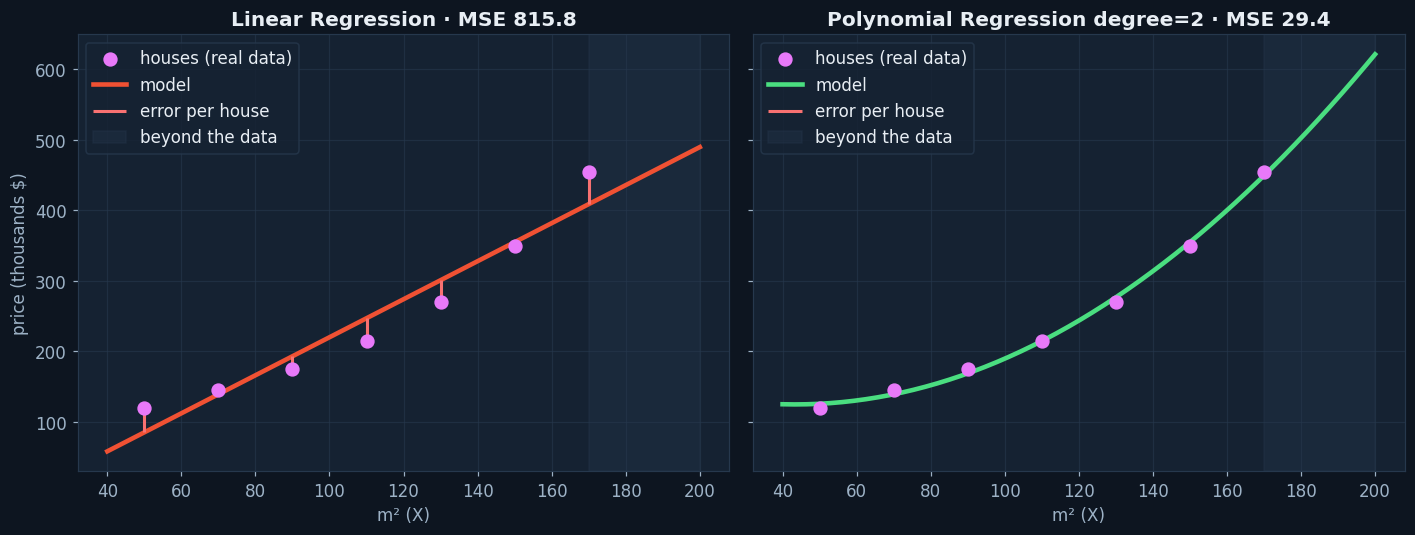

In [ ]:
xs = np.linspace(40, 200, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, model, Xtr, title, col in [
        (axes[0], lin7, X7, "Linear Regression · MSE %.1f" % mean_squared_error(y7, lin7.predict(X7)), C["lin"]),
        (axes[1], quad7, X7_poly, "Polynomial Regression degree=2 · MSE %.1f" % mean_squared_error(y7, quad7.predict(X7_poly)), C["poly"])]:
    xs_in = xs if model is lin7 else poly2.transform(xs)
    pred_pts = model.predict(Xtr)
    ax.scatter(X7, y7, s=70, color=C["data"], zorder=3, label="houses (real data)")
    ax.plot(xs, model.predict(xs_in), color=col, lw=3, label="model")
    ax.vlines(X7.ravel(), y7, pred_pts, color=C["err"], lw=2, label="error per house")
    ax.axvspan(170, 200, color=C["grid"], alpha=0.35, label="beyond the data")
    ax.set(title=title, xlabel="m² (X)")
    ax.legend(loc="upper left")

axes[0].set_ylabel("price (thousands $)")

plt.tight_layout()
plt.show()

**What to look for:** the errors (red lines) for the straight line show a *pattern*: negative at the ends, positive in the middle. That pattern indicates that the data lacks curvature. For the parabola, the errors are small and show no pattern.

---
## 2 A larger dataset with the same behavior

With only 7 data points, we cannot properly perform train/test splits or cross-validation. We generate **300 houses** using the behavior learned earlier (the parabola based on the 7 houses) plus realistic noise. Since *we know the ground truth* (it is a parabola), we will later be able to verify whether cross-validation discovers it on its own.

> In Section 7, we repeat the entire process using a real dataset from scikit-learn.

In [6]:
def true_price(m2):
    """
        The market 'truth': a parabola we learned from the 7 houses.
    """
    return quad7.intercept_ + quad7.coef_[0] * m2 + quad7.coef_[1] * m2**2

n = 300
m2 = RNG.uniform(40, 220, n)

price = true_price(m2) + RNG.normal(0, 22, n)          # noise ~ $22k
houses = pd.DataFrame({"square_meters": m2, "price": price}).sort_values("square_meters").reset_index(drop=True)

X = houses[["square_meters"]].values
y = houses["price"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=32)

print(f"train: {X_train.shape[0]} houses test: {X_test.shape[0]} houses")
houses.describe().round(1)

train: 225 houses test: 75 houses


,square_meters,price
count,300.0,300.0
mean,132.4,337.0
std,52.2,194.9
min,40.0,70.5
25%,91.9,162.3
50%,134.1,289.7
75%,177.0,481.9
max,219.6,802.4


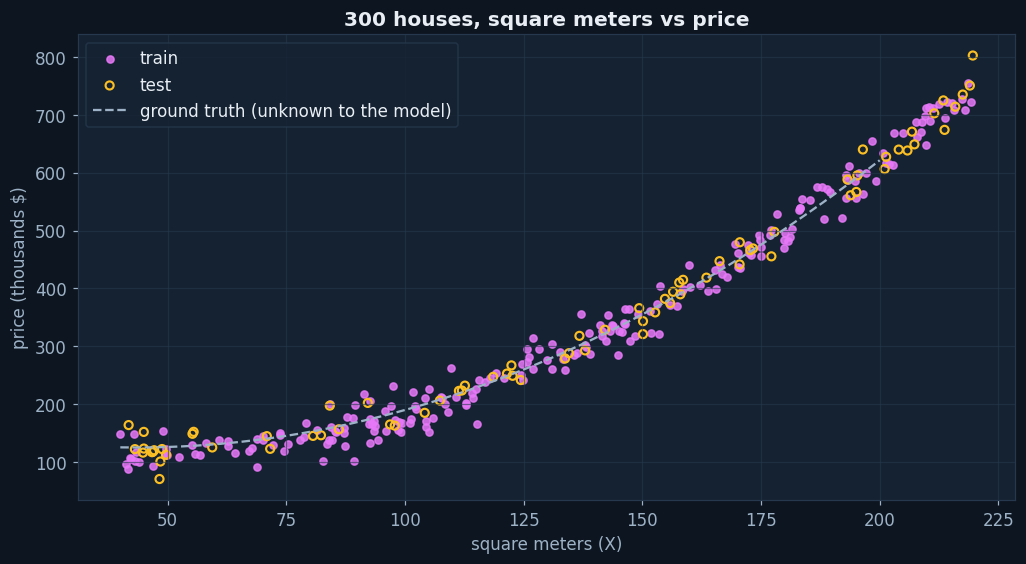

In [ ]:
plt.figure(figsize=(11, 5.5))
plt.scatter(X_train, y_train, s=22, color=C["data"], alpha=0.85, label="train")
plt.scatter(X_test, y_test, s=28, facecolor="none", edgecolor=C["deg"], lw=1.4, label="test")
plt.plot(xs, true_price(xs), color=C["sec"], ls="--", lw=1.5, label="ground truth (unknown to the model)")
plt.title("300 houses · square meters vs price")
plt.xlabel("square meters (X)")
plt.ylabel("price (thousands $)")
plt.legend()

plt.show()

---
## 3 · First, linear regression (and why it fails)

In addition to looking at the MSE, a key plot for detecting the need for curvature is the **residual plot**: residual = `y_actual − ŷ`. If the model is correct, the residuals are randomly distributed around zero. If a **pattern** emerges (a U-shape, an S-shape), the model is missing something.

MSE train = 2688.7 | MSE test = 3980.9 | R² test = 0.906


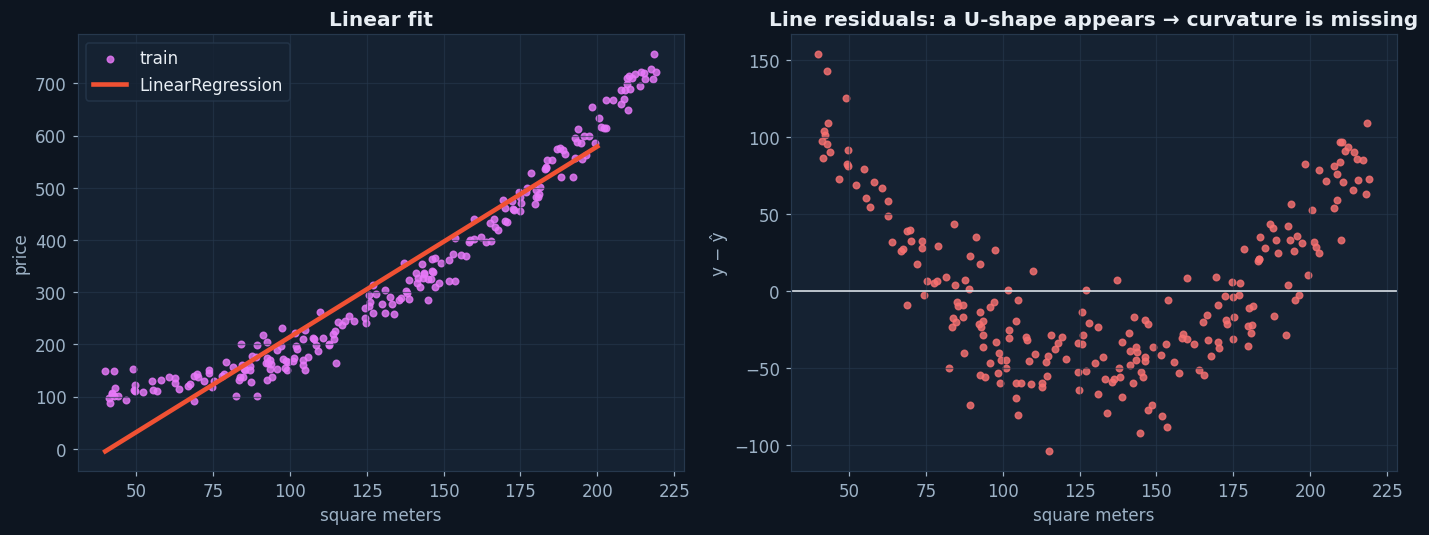

In [9]:
lin = LinearRegression().fit(X_train, y_train)

res_train = y_train - lin.predict(X_train)

print("MSE train = %.1f | MSE test = %.1f | R² test = %.3f" % (
    mean_squared_error(y_train, lin.predict(X_train)),
    mean_squared_error(y_test, lin.predict(X_test)),
    r2_score(y_test, lin.predict(X_test))))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_train, y_train, s=18, color=C["data"], alpha=0.8, label="train")
axes[0].plot(xs, lin.predict(xs), color=C["lin"], lw=3, label="LinearRegression")
axes[0].set(title="Linear fit", xlabel="square meters", ylabel="price")
axes[0].legend()
axes[1].scatter(X_train, res_train, s=18, color=C["err"], alpha=0.8)
axes[1].axhline(0, color=C["text"], lw=1)
axes[1].set(title="Line residuals: a U-shape appears → curvature is missing", xlabel="square meters", ylabel="y − ŷ")

plt.tight_layout()
plt.show()

---
## 4 · What `PolynomialFeatures` does under the hood

It doesn't change the data: it **creates new columns** from `X`. See it for yourself before putting it into a `Pipeline`.

In [10]:
for d in (1, 2, 3):
    pf = PolynomialFeatures(degree=d, include_bias=False)
    Xp = pf.fit_transform(X_train[:3])
    print(f"degree={d} → shape {Xp.shape} · columns: {list(pf.get_feature_names_out(['X']))}")
    print(np.round(Xp, 1), "\n")

degree=1 → shape (3, 1) · columns: ['X']
[[107.7]
 [ 72.1]
 [104.3]] 

degree=2 → shape (3, 2) · columns: ['X', 'X^2']
[[  107.7 11592.2]
 [   72.1  5197.6]
 [  104.3 10887.2]] 

degree=3 → shape (3, 3) · columns: ['X', 'X^2', 'X^3']
[[1.0770000e+02 1.1592200e+04 1.2480937e+06]
 [7.2100000e+01 5.1976000e+03 3.7472100e+05]
 [1.0430000e+02 1.0887200e+04 1.1359877e+06]] 



Using `include_bias=False` avoids adding the column of ones (since `LinearRegression` already handles the intercept). This ensures the features are exactly `[X, X², X³]`, just as in the class.

And the convenient way to chain the transformation and the model is by using a **`Pipeline`**: this way, new data undergoes the same transformation before a prediction is made, and later on, `GridSearchCV` can search across the `degree` parameter as if it were any other hyperparameter.

In [11]:
def poly_model(degree):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("reg",  LinearRegression()),
    ])

quad = poly_model(2).fit(X_train, y_train)
print("MSE train = %.1f · MSE test = %.1f · R² test = %.3f" % (
    mean_squared_error(y_train, quad.predict(X_train)),
    mean_squared_error(y_test, quad.predict(X_test)),
    r2_score(y_test, quad.predict(X_test))))
print("learned coefficients (β1, β2):", quad.named_steps["reg"].coef_.round(4), 
    "· intercept β0:", round(quad.named_steps["reg"].intercept_, 2))

MSE train = 486.5 · MSE test = 374.1 · R² test = 0.991
learned coefficients (β1, β2): [-1.536   0.0197] · intercept β0: 141.79


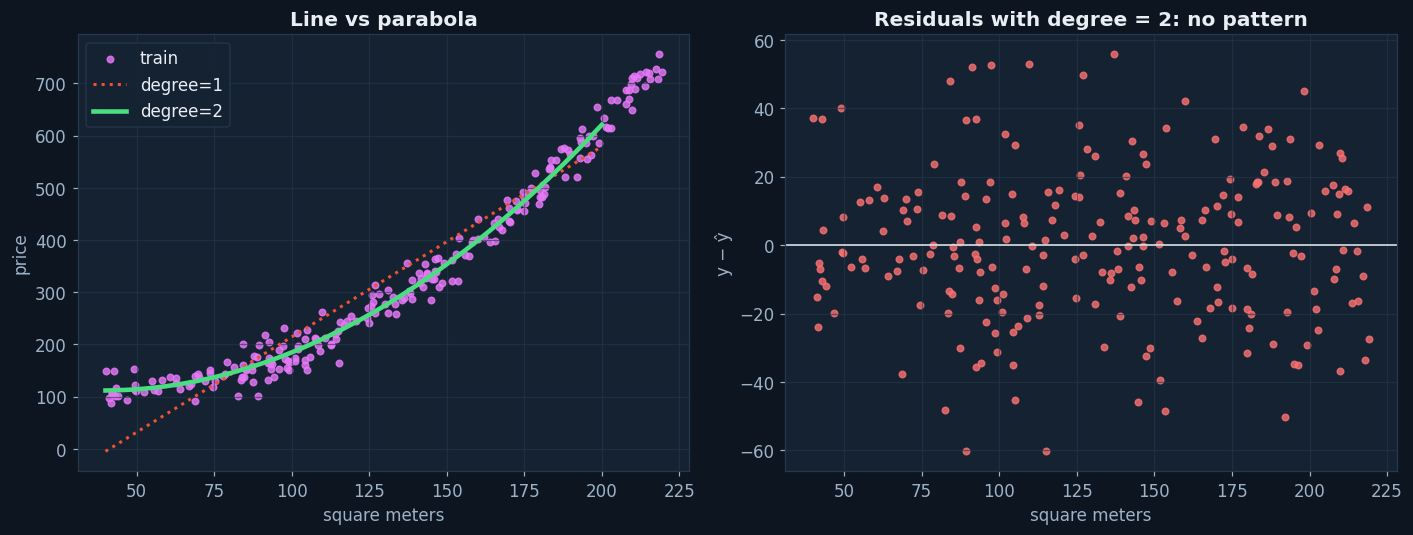

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_train, y_train, s=18, color=C["data"], alpha=0.8, label="train")
axes[0].plot(xs, lin.predict(xs), color=C["lin"], lw=2, ls=":", label="degree=1")
axes[0].plot(xs, quad.predict(xs), color=C["poly"], lw=3, label="degree=2")
axes[0].set(title="Line vs parabola", xlabel="square meters", ylabel="price")
axes[0].legend()
axes[1].scatter(X_train, y_train - quad.predict(X_train), s=18, color=C["err"], alpha=0.8)
axes[1].axhline(0, color=C["text"], lw=1)
axes[1].set(title="Residuals with degree = 2: no pattern", xlabel="square meters", ylabel="y − ŷ")

plt.tight_layout()
plt.show()

---
## 5 · `degree = 1 … 10`: train vs. test

Now, the key question: **which degree should we choose?** First, the naive approach: we train a model for each degree and observe the training and test errors.

Note two things:
- the **training error always decreases** as the degree increases (more flexibility = the model fits the points more closely),
- the **test error** drops sharply from `degree=1` to `degree=2` but **stops improving** thereafter: the extra degrees add no information, only unnecessary flexibility.

With 225 well-distributed houses, that excess flexibility causes little harm *within* the data range. Where it *does* cause problems is during **extrapolation** (see the next graph) and when there is **limited data** (section 6.4).

In [14]:
degrees = list(range(1, 11))
mse_train, mse_test = [], []
for d in degrees: 
    m = poly_model(d).fit(X_train, y_train) 
    mse_train.append(mean_squared_error(y_train, m.predict(X_train))) 
    mse_test.append(mean_squared_error(y_test, m.predict(X_test)))

table = pd.DataFrame({"degree": degrees, "MSE train": mse_train, "MSE test": mse_test}).round(1)
table

,degree,MSE train,MSE test
0,1,2688.7,3980.9
1,2,486.5,374.1
2,3,484.5,370.7
3,4,484.4,372.9
4,5,484.3,375.2
5,6,483.0,382.2
6,7,481.3,392.2
7,8,480.6,400.0
8,9,480.6,401.7
9,10,480.7,397.0


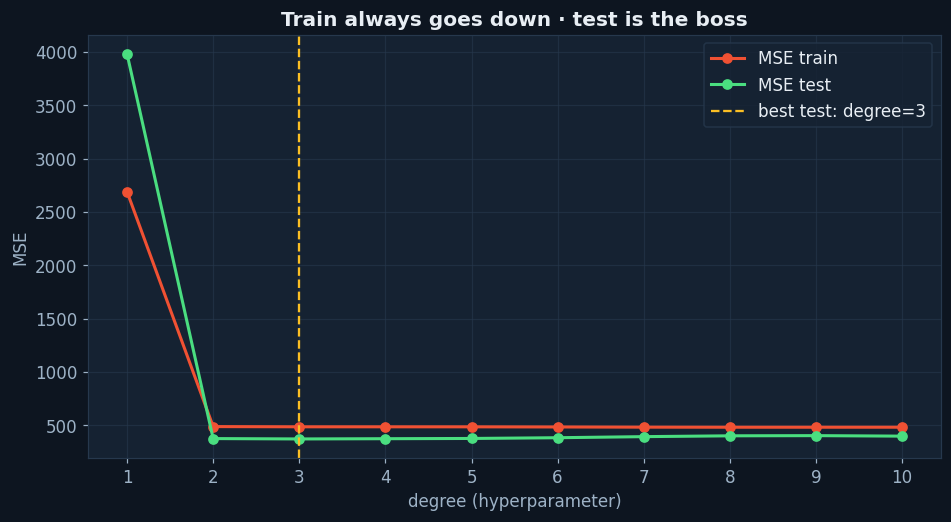

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(degrees, mse_train, "o-", color=C["lin"], lw=2, label="MSE train")
plt.plot(degrees, mse_test, "o-", color=C["poly"], lw=2, label="MSE test")
best_d = degrees[int(np.argmin(mse_test))]
plt.axvline(best_d, color=C["deg"], ls="--", label=f"best test: degree={best_d}")
plt.xticks(degrees)
plt.xlabel("degree (hyperparameter)")
plt.ylabel("MSE")
plt.title("Train always goes down · test is the boss")
plt.legend()
plt.show()

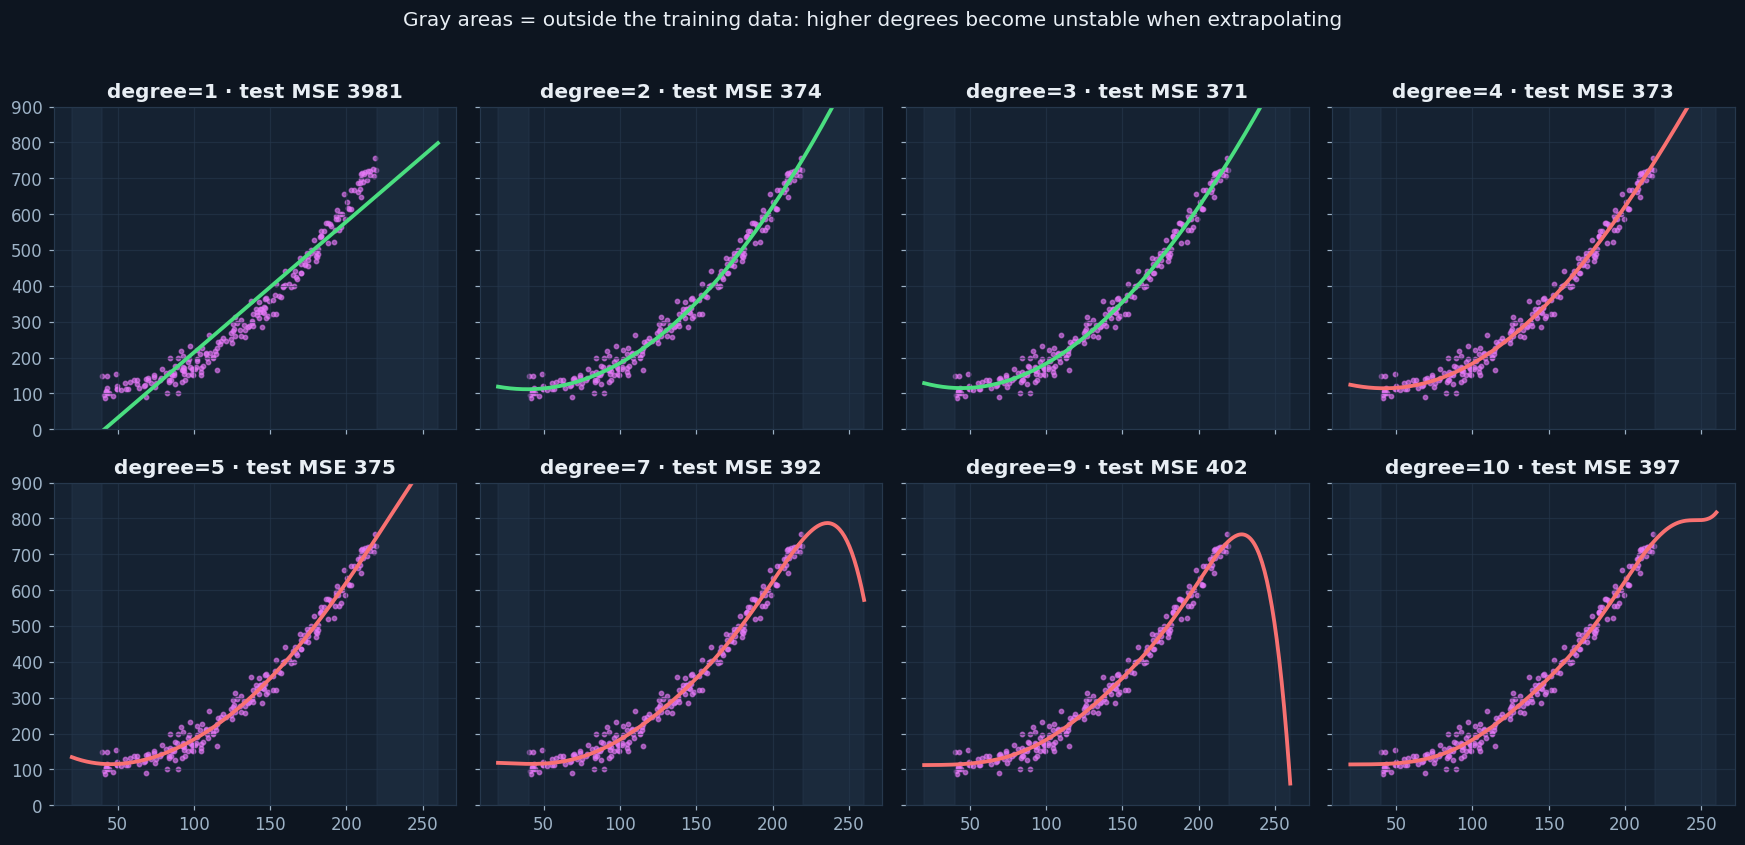

In [16]:
# What each degree looks like, including what happens OUTSIDE the data range (extrapolation)
xs_ext = np.linspace(20, 260, 300).reshape(-1, 1)
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), sharex=True, sharey=True)

for ax, d in zip(axes.ravel(), [1, 2, 3, 4, 5, 7, 9, 10]):
    m = poly_model(d).fit(X_train, y_train)
    ax.scatter(X_train, y_train, s=8, color=C["data"], alpha=0.6)
    ax.plot(xs_ext, m.predict(xs_ext), color=C["poly"] if d <= 3 else C["err"], lw=2.5)
    ax.axvspan(20, 40, color=C["grid"], alpha=0.4); ax.axvspan(220, 260, color=C["grid"], alpha=0.4)
    ax.set_title(f"degree={d} · test MSE {mse_test[d-1]:.0f}")
    ax.set_ylim(0, 900)

fig.suptitle("Gray areas = outside the training data: higher degrees become unstable when extrapolating", y=1.02)

plt.tight_layout()
plt.show()

---
## 6 Choosing the degree using cross-validation

A single train/test split depends on *which houses* ended up in the test set. **Cross-validation** (`KFold`) repeats the experiment K times using different partitions and averages the results, making the decision much more stable.

We move from manual to increasingly automated approaches:

1. `cross_val_score` manually, degree by degree.
2. `validation_curve`: the train vs. validation curve in a single call.
3. `GridSearchCV` on the `Pipeline`: searches for the optimal `poly__degree` and returns the best, already-trained model.

> We use `scoring="neg_mean_squared_error"` because scikit-learn always **maximizes** the score (higher is better). That is why the MSE appears as a negative value; we flip the sign to interpret it.

In [17]:
cv = KFold(n_splits=5, shuffle=True, random_state=32)

cv_mean, cv_std, cv_all = [], [], []
for d in degrees:
    scores = -cross_val_score(poly_model(d), X_train, y_train, cv=cv, scoring="neg_mean_squared_error")
    cv_all.append(scores); cv_mean.append(scores.mean()); cv_std.append(scores.std())
    print(f"degree={d:2d} · MSE by fold: {np.round(scores, 0)} · mean {scores.mean():7.1f} ± {scores.std():5.1f}")

degree= 1 · MSE by fold: [2341. 3193. 2519. 2859. 2814.] · mean  2745.3 ± 294.2
degree= 2 · MSE by fold: [416. 546. 654. 410. 509.] · mean   507.1 ±  90.5
degree= 3 · MSE by fold: [411. 543. 657. 417. 507.] · mean   507.1 ±  90.7
degree= 4 · MSE by fold: [411. 548. 711. 442. 513.] · mean   524.7 ± 104.9
degree= 5 · MSE by fold: [420. 548. 722. 458. 513.] · mean   532.3 ± 104.6
degree= 6 · MSE by fold: [418. 545. 723. 452. 526.] · mean   533.0 ± 105.8
degree= 7 · MSE by fold: [411. 539. 718. 450. 552.] · mean   534.0 ± 106.2
degree= 8 · MSE by fold: [404. 535. 715. 452. 575.] · mean   536.2 ± 107.7
degree= 9 · MSE by fold: [404. 528. 719. 454. 583.] · mean   537.7 ± 109.2
degree=10 · MSE by fold: [415. 512. 726. 454. 583.] · mean   537.9 ± 109.7


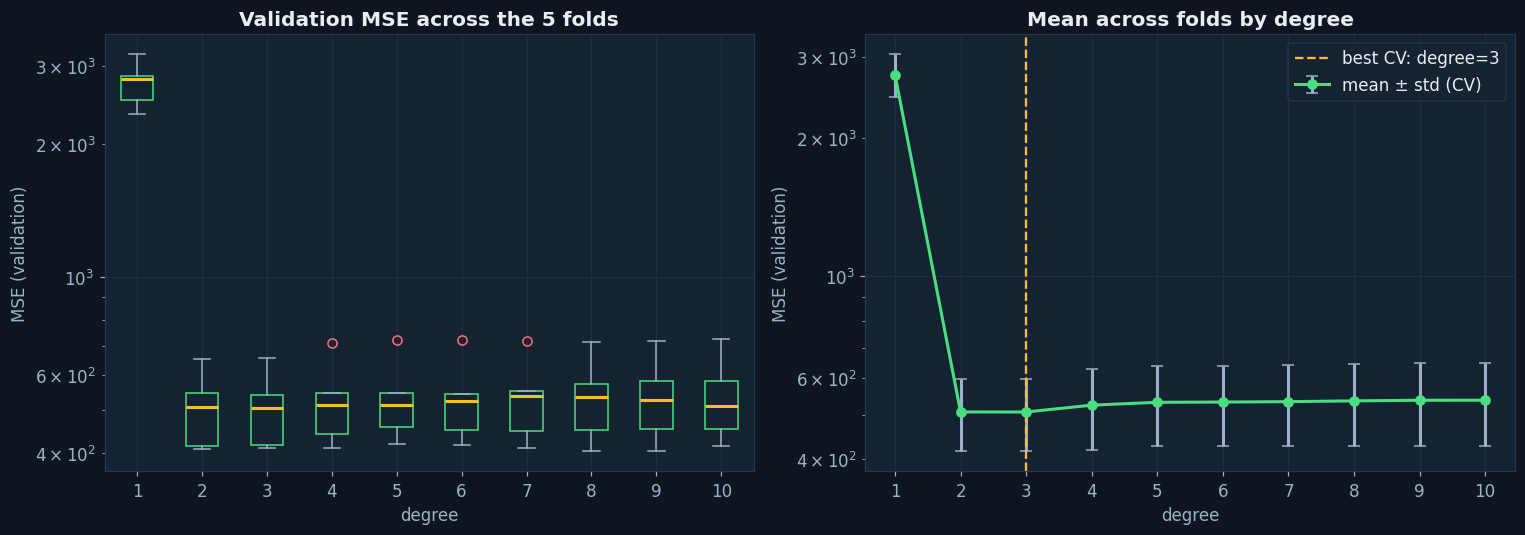

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(cv_all, labels=degrees, patch_artist=True,
                boxprops=dict(facecolor=C["panel"], color=C["poly"]), medianprops=dict(color=C["deg"], lw=2),
                whiskerprops=dict(color=C["sec"]), capprops=dict(color=C["sec"]), flierprops=dict(markeredgecolor=C["err"]))
axes[0].set(title="Validation MSE across the 5 folds", xlabel="degree", ylabel="MSE (validation)", yscale="log")
axes[1].errorbar(degrees, cv_mean, yerr=cv_std, fmt="o-", color=C["poly"], ecolor=C["sec"], capsize=4, lw=2, label="mean ± std (CV)")
best_cv = degrees[int(np.argmin(cv_mean))]
axes[1].axvline(best_cv, color=C["deg"], ls="--", label=f"best CV: degree={best_cv}")
axes[1].set(title="Mean across folds by degree", xlabel="degree", ylabel="MSE (validation)", yscale="log", xticks=degrees)
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.2 `validation_curve`: training vs. validation in a single call

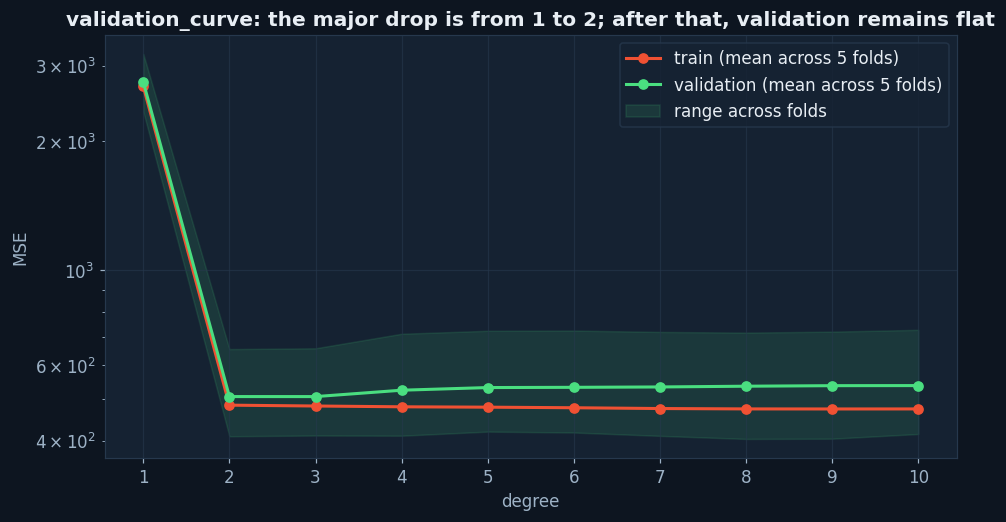

In [20]:
tr_scores, va_scores = validation_curve(
    poly_model(1), X_train, y_train,
    param_name="poly__degree", param_range=degrees,
    cv=cv, scoring="neg_mean_squared_error")

tr_mse, va_mse = -tr_scores.mean(axis=1), -va_scores.mean(axis=1)
plt.figure(figsize=(10, 5))
plt.plot(degrees, tr_mse, "o-", color=C["lin"], lw=2, label="train (mean across 5 folds)")
plt.plot(degrees, va_mse, "o-", color=C["poly"], lw=2, label="validation (mean across 5 folds)")
plt.fill_between(degrees, -va_scores.min(axis=1), -va_scores.max(axis=1), color=C["poly"], alpha=0.12, label="range across folds")

plt.yscale("log")
plt.xticks(degrees)
plt.xlabel("degree")
plt.ylabel("MSE")
plt.title("validation_curve: the major drop is from 1 to 2; after that, validation remains flat")
plt.legend()

plt.show()

### 6.3 · `GridSearchCV` — the professional approach

`GridSearchCV` takes the `Pipeline`, the hyperparameter grid (`poly__degree` = step name + `__` + parameter name), and the CV strategy. It tests all combinations, selects the best one, and **retrains it using the entire training set**.

In [21]:
grid = GridSearchCV(
    poly_model(1),
    param_grid={"poly__degree": degrees},
    cv=cv, scoring="neg_mean_squared_error", return_train_score=True)
grid.fit(X_train, y_train)

print("Best hyperparameter :", grid.best_params_)
print("Best CV MSE          : %.1f" % -grid.best_score_)
print("Test MSE (never seen): %.1f · Test R² %.3f" % (
    mean_squared_error(y_test, grid.predict(X_test)), r2_score(y_test, grid.predict(X_test))))

res = pd.DataFrame(grid.cv_results_)[["param_poly__degree", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]]

res["mean_train_score"] = -res["mean_train_score"]
res["mean_test_score"] = -res["mean_test_score"]

res.rename(columns={"param_poly__degree": "degree", "mean_train_score": "MSE train", "mean_test_score": "MSE validation", "std_test_score": "std", "rank_test_score": "ranking"}).round(1)

Best hyperparameter : {'poly__degree': 3}
Best CV MSE          : 507.1
Test MSE (never seen): 370.7 · Test R² 0.991


,degree,MSE train,MSE validation,std,ranking
0,1,2682.3,2745.3,294.2,10
1,2,484.3,507.1,90.5,2
2,3,482.1,507.1,90.7,1
3,4,480.0,524.7,104.9,3
4,5,479.1,532.3,104.6,4
5,6,477.6,533.0,105.8,5
6,7,475.6,534.0,106.2,6
7,8,474.6,536.2,107.7,7
8,9,474.5,537.7,109.2,8
9,10,474.6,537.9,109.7,9


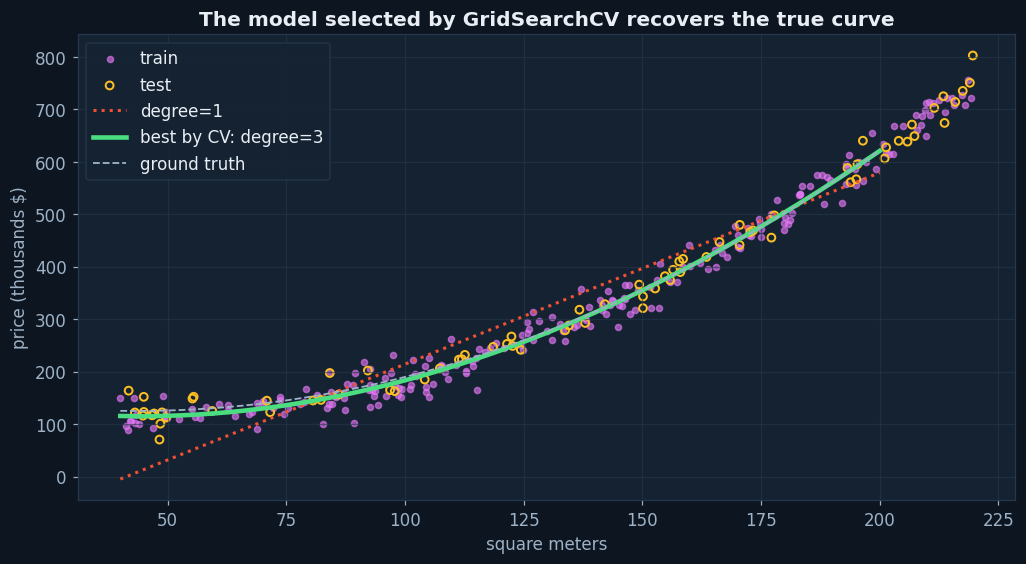

In [22]:
best = grid.best_estimator_

plt.figure(figsize=(11, 5.5))
plt.scatter(X_train, y_train, s=16, color=C["data"], alpha=0.6, label="train")
plt.scatter(X_test, y_test, s=26, facecolor="none", edgecolor=C["deg"], lw=1.3, label="test")
plt.plot(xs, lin.predict(xs), color=C["lin"], lw=2, ls=":", label="degree=1")
plt.plot(xs, best.predict(xs), color=C["poly"], lw=3, label=f"best by CV: degree={grid.best_params_['poly__degree']}")
plt.plot(xs, true_price(xs), color=C["sec"], ls="--", lw=1.2, label="ground truth")
plt.title("The model selected by GridSearchCV recovers the true curve")
plt.xlabel("square meters")
plt.ylabel("price (thousands $)")
plt.legend()
plt.show()

**The key point:** cross-validation independently determined that the curve is of degree 2 (or the closest approximation allowed by the noise) **without being told the truth**. That is precisely what "testing and evaluating which one generalizes best" entails.

Furthermore, notice that the test error of the best model is close to the noise variance (22² ≈ 484): it cannot be reduced much further, because the remainder is noise, not signal.

### 6.4 When overfitting really bites: limited data

We repeat the experiment using only **20 houses** from the same market. With few data points, a high-degree polynomial has the freedom to "pass through" the noise, and cross-validation penalizes it severely.

Two best practices are illustrated here:
- We scale `X` using `StandardScaler` **before** applying `PolynomialFeatures`: with areas up to 220 m², `X⁸` reaches ~10¹⁸, leading to numerical instability. Scaling does not alter the shape of the curve, only the arithmetic.
- With 20 houses, we use **leave-one-out** (`LeaveOneOut`): 20 folds of one house each, as shown on slide 22 of the lecture.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut

def poly_model_scaled(degree):
    return Pipeline([("scale", StandardScaler()),
                    ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
                    ("reg", LinearRegression())])

rng20 = np.random.default_rng(32)
m2_20 = rng20.uniform(40, 220, 20)
X20 = m2_20.reshape(-1, 1)
y20 = true_price(m2_20) + rng20.normal(0, 25, 20)

grid20 = GridSearchCV(poly_model_scaled(1), {"poly__degree": range(1, 10)}, cv=LeaveOneOut(),
                        scoring="neg_mean_squared_error", return_train_score=True).fit(X20, y20)
r20 = pd.DataFrame(grid20.cv_results_)
d20 = r20["param_poly__degree"].astype(int).values
print("Best degree with 20 houses and leave-one-out:", grid20.best_params_["poly__degree"])
pd.DataFrame({"degree": d20, "MSE train": (-r20["mean_train_score"]).round(0), "MSE validation (LOO)": (-r20["mean_test_score"]).round(0)})

Best degree with 20 houses and leave-one-out: 2


,degree,MSE train,MSE validation (LOO)
0,1,3183.0,4257.0
1,2,693.0,893.0
2,3,690.0,1008.0
3,4,656.0,1109.0
4,5,625.0,11467.0
5,6,546.0,45768.0
6,7,420.0,80052.0
7,8,349.0,1989.0
8,9,342.0,421636.0


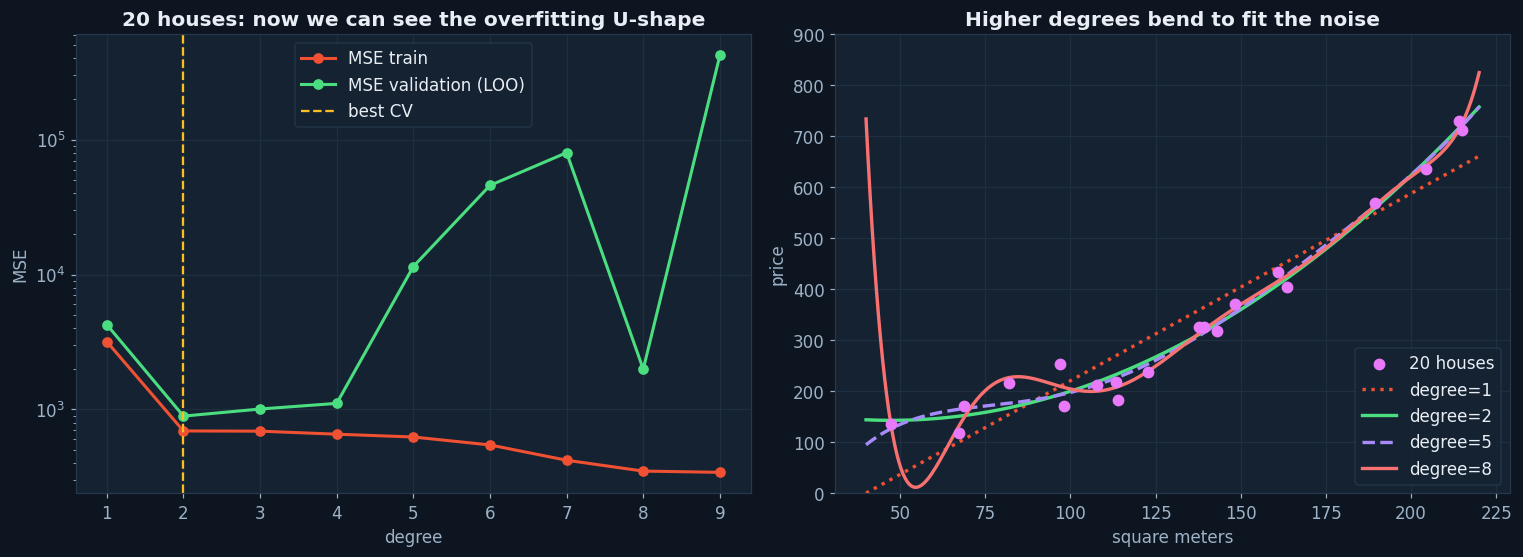

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

axes[0].plot(d20, -r20["mean_train_score"], "o-", color=C["lin"], lw=2, label="MSE train")
axes[0].plot(d20, -r20["mean_test_score"], "o-", color=C["poly"], lw=2, label="MSE validation (LOO)")
axes[0].axvline(grid20.best_params_["poly__degree"], color=C["deg"], ls="--", label="best CV")
axes[0].set(title="20 houses: now we can see the overfitting U-shape", xlabel="degree", ylabel="MSE", yscale="log", xticks=d20)
axes[0].legend()

x20s = np.linspace(40, 220, 300).reshape(-1, 1)
axes[1].scatter(X20, y20, s=45, color=C["data"], zorder=3, label="20 houses")
for d, col, ls in [(1, C["lin"], ":"), (2, C["poly"], "-"), (5, C["x3"], "--"), (8, C["err"], "-")]:
    axes[1].plot(x20s, poly_model_scaled(d).fit(X20, y20).predict(x20s), color=col, lw=2.2, ls=ls, label=f"degree={d}")
axes[1].set(title="Higher degrees bend to fit the noise", xlabel="square meters", ylabel="price", ylim=(0, 900))
axes[1].legend()
plt.tight_layout()
plt.show()

**What to look for:** the training error (red) keeps dropping to near zero—with 20 points, a degree-8 model practically memorizes them. The validation error (green) drops until degree 2 and then **explodes**. That is the visual definition of overfitting, and the reason why the degree is never chosen by looking at the training error.

---
## 7 Using a real scikit-learn dataset: `load_diabetes`

Up to this point, we knew a curve existed. In real-world scenarios, you don't. `load_diabetes` is included in scikit-learn (no download required): it contains data on 442 patients and 10 variables, with a target measuring disease progression one year later.

We will use a single feature `bmi` (body mass index) and let `GridSearchCV` decide whether it is worth adding a curve.

In [25]:
from sklearn.datasets import load_diabetes

diab = load_diabetes(as_frame=True)
Xd = diab.data[["bmi"]].values
yd = diab.target.values
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.25, random_state=32)

print(diab.frame[["bmi", "target"]].describe().round(3))

           bmi   target
count  442.000  442.000
mean    -0.000  152.133
std      0.048   77.093
min     -0.090   25.000
25%     -0.034   87.000
50%     -0.007  140.500
75%      0.031  211.500
max      0.171  346.000


In [26]:
grid_d = GridSearchCV(poly_model(1), {"poly__degree": range(1, 9)}, cv=KFold(5, shuffle=True, random_state=32),
                      scoring="neg_mean_squared_error", return_train_score=True).fit(Xd_tr, yd_tr)
res_d = pd.DataFrame(grid_d.cv_results_)
deg_d = res_d["param_poly__degree"].astype(int).values
mean_d, std_d = -res_d["mean_test_score"].values, res_d["std_test_score"].values

print("Best degree according to the CV mean:", grid_d.best_params_["poly__degree"])
pd.DataFrame({"degree": deg_d, "Validation MSE": mean_d.round(0), "std across folds": std_d.round(0)})

Best degree according to the CV mean: 6


,degree,Validation MSE,std across folds
0,1,4014.0,591.0
1,2,4026.0,590.0
2,3,4052.0,615.0
3,4,4099.0,614.0
4,5,4023.0,640.0
5,6,3975.0,674.0
6,7,4073.0,671.0
7,8,4615.0,1344.0


Look at the table: the validation mean is almost identical for all degrees (≈ 4000), and the **deviation across folds is ≈ 600**. In other words, the difference between "the best" and `degree=1` is **much smaller than the noise inherent in the validation itself**. `GridSearchCV` returns the numerical maximum, but that maximum does not represent a real difference.

A widely used rule of thumb (**one-standard-error rule**): among models with a mean within one standard deviation of the best one, **choose the simplest**.

best mean: degree=6 (MSE 3975 ± 674)
1-SE threshold = 4649 → the simplest degree within the threshold is degree=1


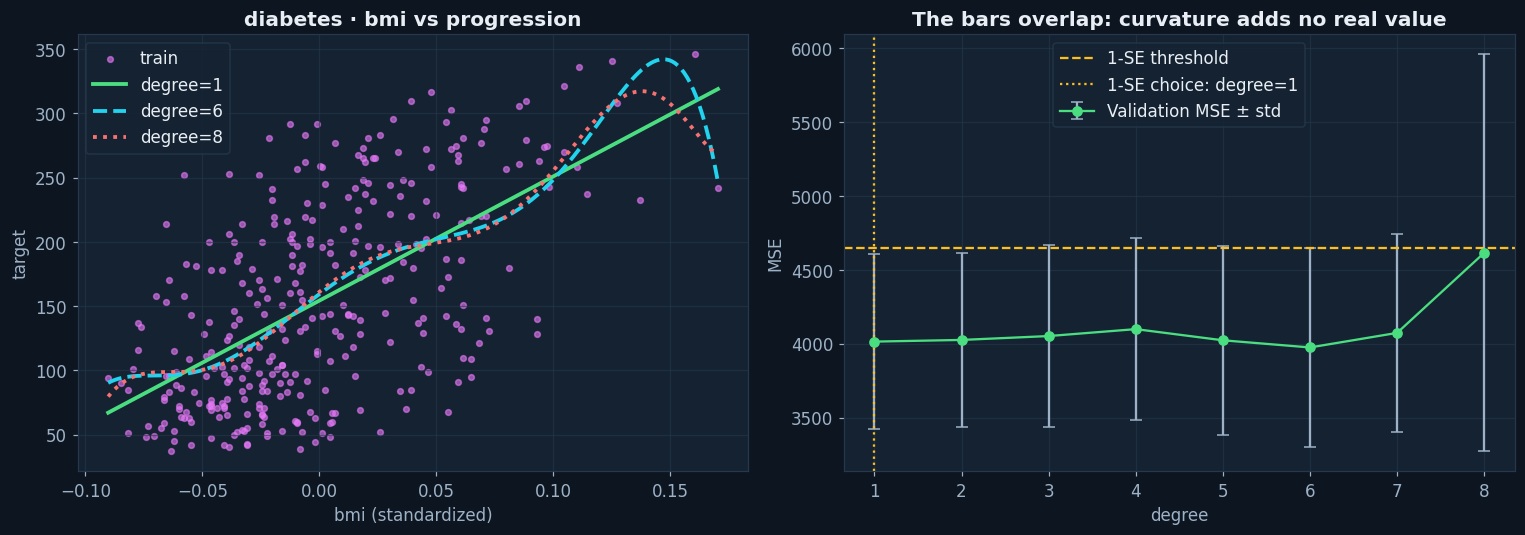

In [27]:
i_best = int(np.argmin(mean_d))
umbral = mean_d[i_best] + std_d[i_best]
deg_1se = int(deg_d[np.argmax(mean_d <= umbral)])      # the first (simplest) degree that meets the threshold

print(f"best mean: degree={deg_d[i_best]} (MSE {mean_d[i_best]:.0f} ± {std_d[i_best]:.0f})")
print(f"1-SE threshold = {umbral:.0f} → the simplest degree within the threshold is degree={deg_1se}")

xd = np.linspace(Xd.min(), Xd.max(), 200).reshape(-1, 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(Xd_tr, yd_tr, s=14, color=C["data"], alpha=0.6, label="train")

for d, col, ls in [(deg_1se, C["poly"], "-"), (int(deg_d[i_best]), C["x2"], "--"), (8, C["err"], ":")]:
    m = poly_model(d).fit(Xd_tr, yd_tr)
    axes[0].plot(xd, m.predict(xd), color=col, lw=2.5, ls=ls, label=f"degree={d}")

axes[0].set(title="diabetes · bmi vs progression", xlabel="bmi (standardized)", ylabel="target")
axes[0].legend()
axes[1].errorbar(deg_d, mean_d, yerr=std_d, fmt="o-", color=C["poly"], ecolor=C["sec"], capsize=4, label="Validation MSE ± std")
axes[1].axhline(umbral, color=C["deg"], ls="--", label="1-SE threshold")
axes[1].axvline(deg_1se, color=C["deg"], ls=":", label=f"1-SE choice: degree={deg_1se}")
axes[1].set(title="The bars overlap: curvature adds no real value", xlabel="degree", ylabel="MSE")
axes[1].legend()

plt.tight_layout()
plt.show()

**Lesson:** Polynomial regression is not "better" by default. With `bmi`, increasing the degree does not significantly improve validation results, and from `degree=7–8` onwards, performance clearly worsens (observe the increasing deviation: the extremes, where there are few patients, become unstable). Cross-validation tells you **when** it is worth using a curve and when you should stick with a straight line.